In [1]:
# ===============================
# Path setup + autoreload
# ===============================

import sys
from pathlib import Path
import scanpy as sc
import pandas as pd

# Project root: C:\Users\user\Desktop\multiomic_vae
PROJECT_ROOT = Path(r"C:\Users\user\Desktop\multiomic_vae")

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Define important directories
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = PROJECT_ROOT / "processed_data"

# Jupyter autoreload (VERY IMPORTANT)
%load_ext autoreload
%autoreload 2

sc.set_figure_params(dpi=80, dpi_save=80, frameon=True, facecolor='white', figsize=(5,4))

# 1) Preprocessing Cell * Gene

In [2]:
# ===============================
# Load raw scRNA-seq data
# ===============================

from multiomic_vae.data.preprocess_rna import load_cell_gene

# Path to raw RNA data
rna_path = DATA_DIR / "pbmc_3k" / "filtered_feature_bc_matrix.h5"

# Load cell × gene matrix
adata_rna = load_cell_gene(rna_path)

# Make gene names unique
adata_rna.var_names_make_unique()

# Add sample label (used later for QC and batch-aware steps)
adata_rna.obs["sample"] = "s1d1"

adata_rna

C:\Users\user\anaconda3\envs\peakvi\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
C:\Users\user\anaconda3\envs\peakvi\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 3009 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

### 1.1) Quality control (QC): annotation, visualization, and filtering
Mitochondrial, Ribosomal, and Hemoglobin genes were annotated and used to filter low-quality cells.

In [3]:
# ===============================
# QC annotation and metrics
# ===============================

from multiomic_vae.data.preprocess_rna import annotate_qc, compute_qc_metrics

# Annotate genes for QC (mitochondrial, ribosomal, hemoglobin)
adata_rna = annotate_qc(adata_rna)

# Compute QC metrics per cell using annotated gene groups
adata_rna = compute_qc_metrics(adata_rna)

adata_rna.obs.head()

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
AAACAGCCAACAGGTG-1,s1d1,1003,6.911747,1796.0,7.493874,35.356347,42.316258,53.452116,71.993318,328.0,5.796058,18.262806,113.0,4.736198,6.291760,0.0,0.0,0.0
AAACATGCAACAACAA-1,s1d1,1956,7.579168,3997.0,8.293550,22.867150,29.697273,39.104328,57.668251,325.0,5.786897,8.131098,33.0,3.526361,0.825619,0.0,0.0,0.0
AAACATGCACCTGGTG-1,s1d1,102,4.634729,460.0,6.133398,88.695652,99.565217,100.000000,100.000000,358.0,5.883322,77.826088,23.0,3.178054,5.000000,0.0,0.0,0.0
AAACCAACACAGCCTG-1,s1d1,870,6.769642,1565.0,7.356280,35.079872,43.450479,56.230032,76.357827,263.0,5.575949,16.805113,86.0,4.465908,5.495208,0.0,0.0,0.0
AAACCAACAGCAAGAT-1,s1d1,968,6.876265,1574.0,7.362010,28.144854,36.975858,49.682338,70.266836,191.0,5.257495,12.134688,91.0,4.521789,5.781449,0.0,0.0,0.0


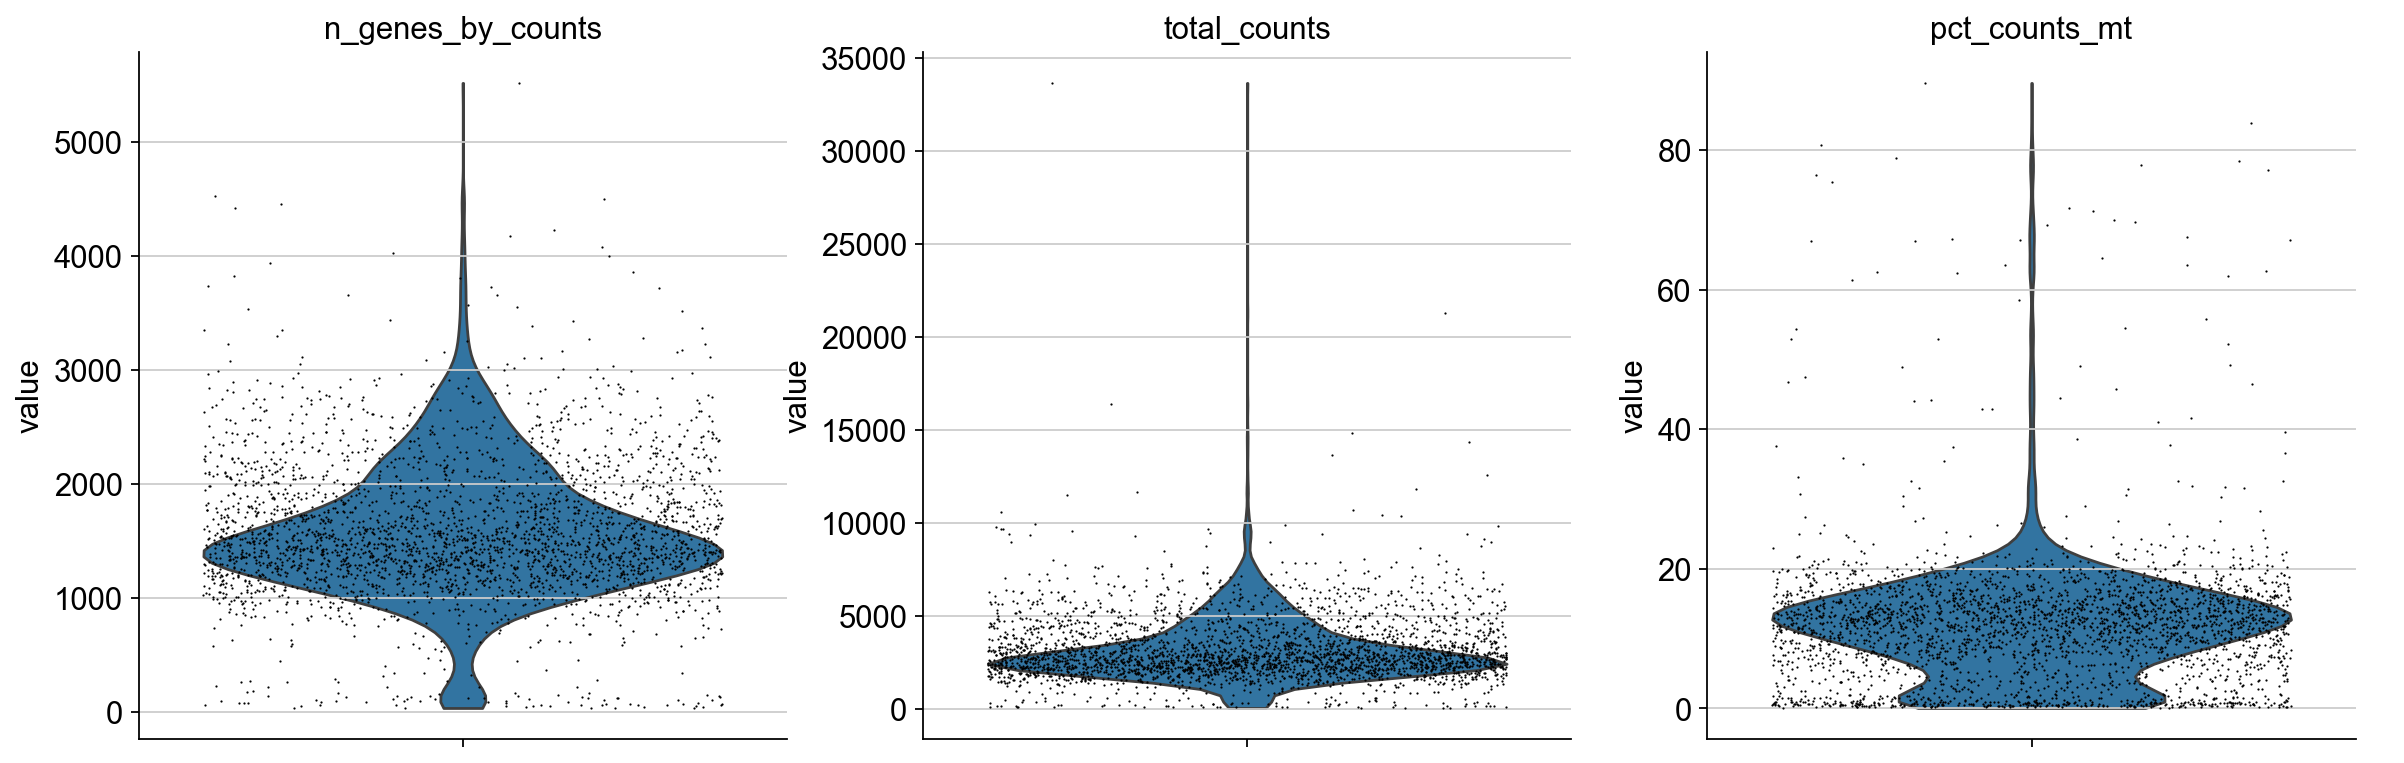

In [4]:
# ===============================
# QC visualization: mitochondrial genes
# ===============================

sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

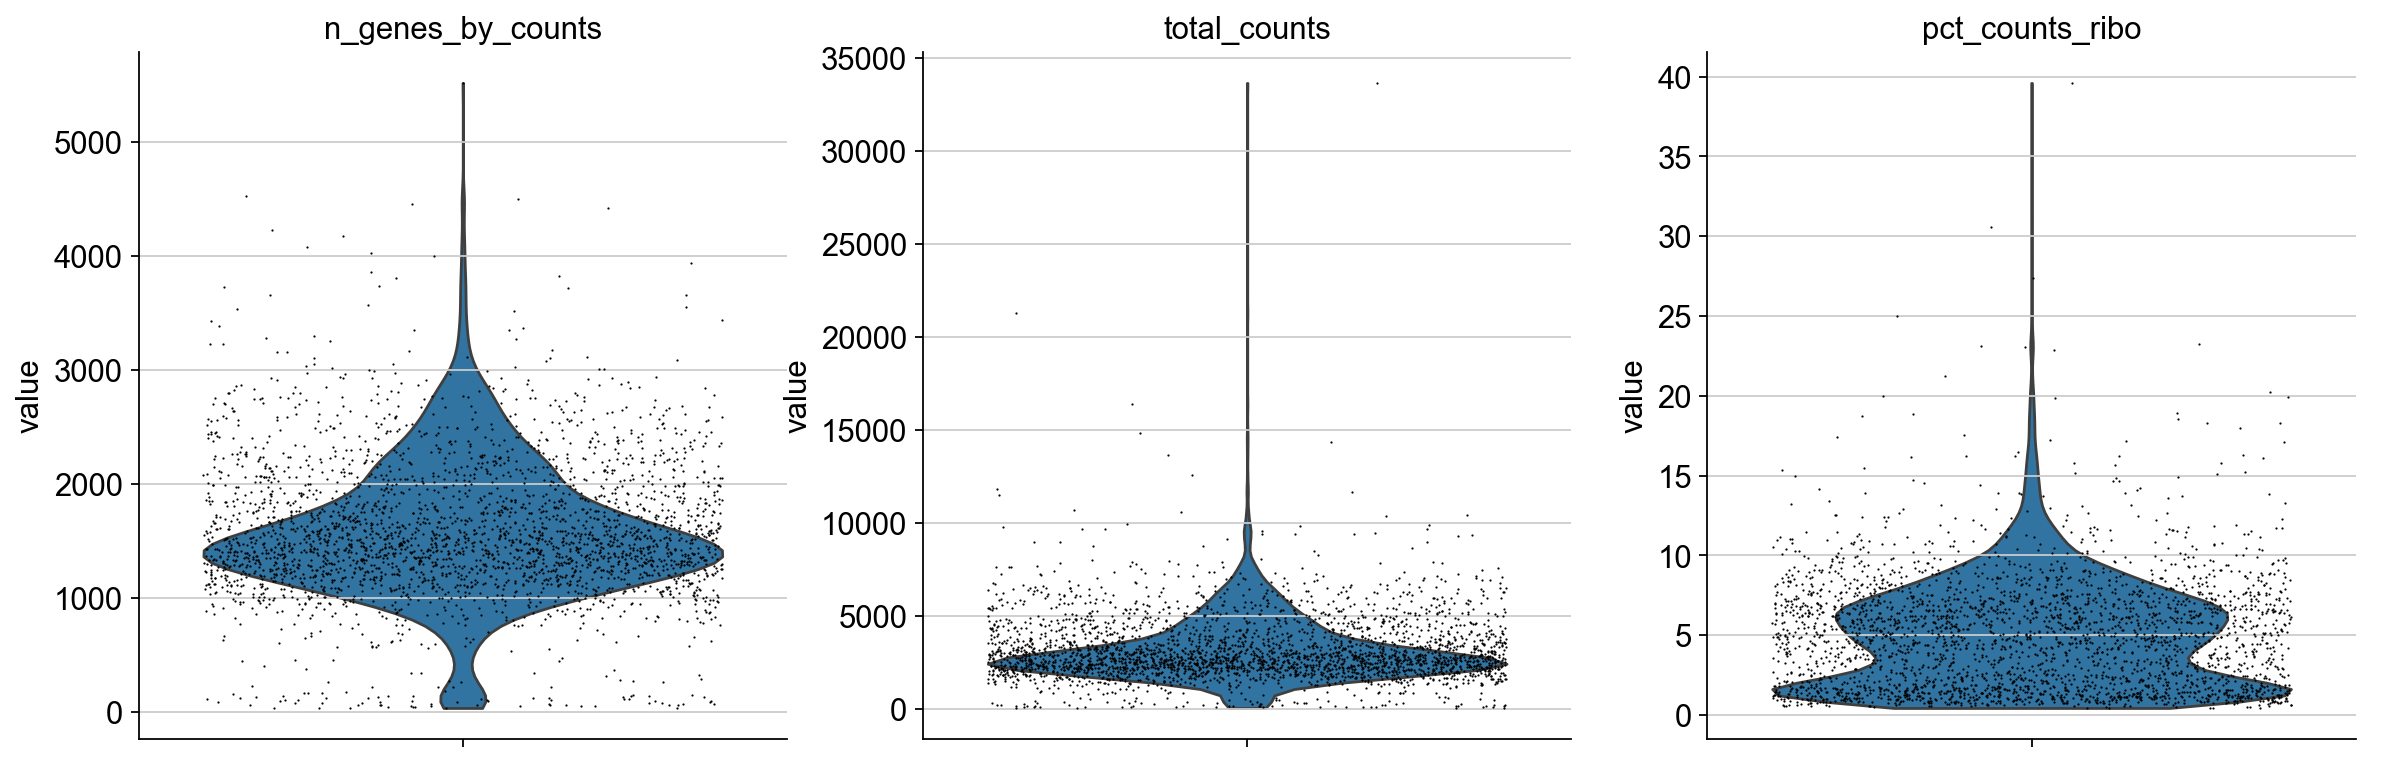

In [5]:
# ===============================
# QC visualization: ribosomal genes
# ===============================

sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True
)

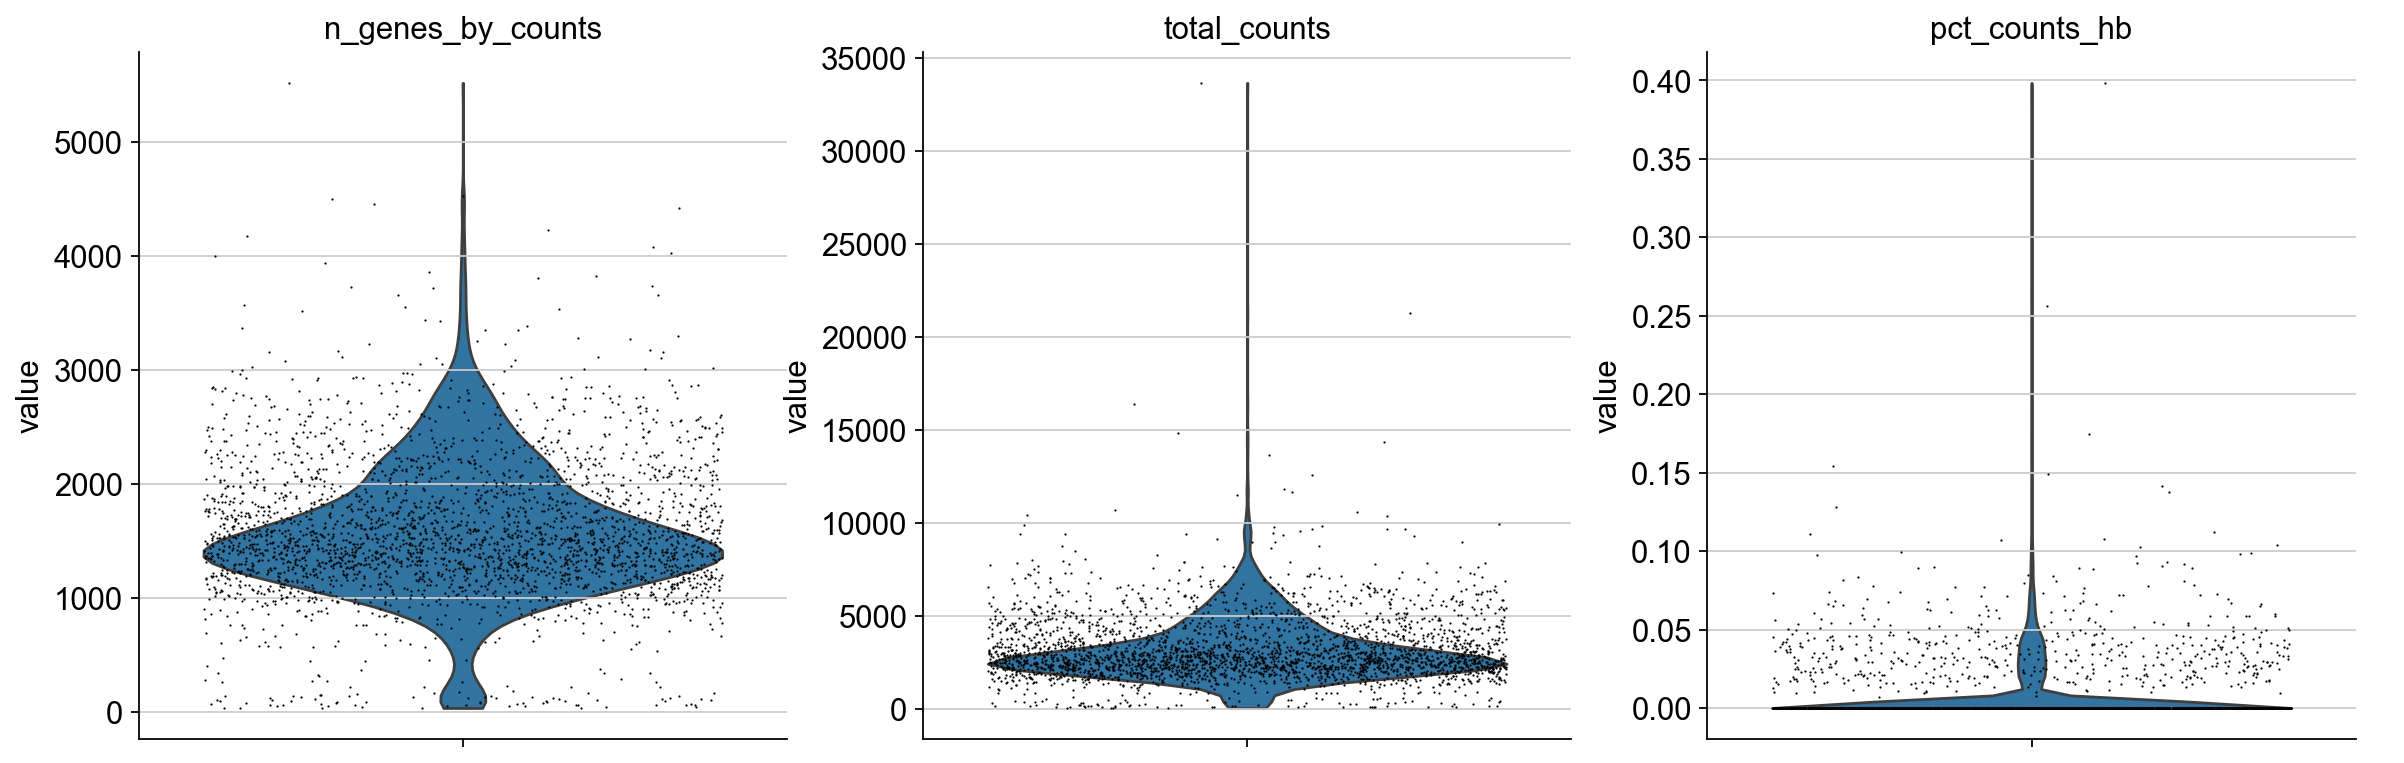

In [6]:
# ===============================
# QC visualization: hemoglobin genes
# ===============================

sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True
)

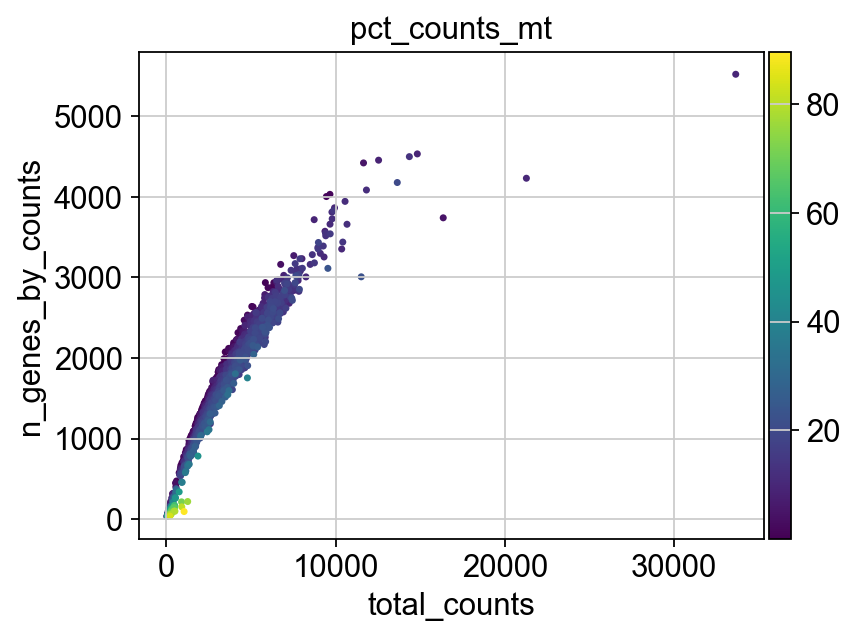

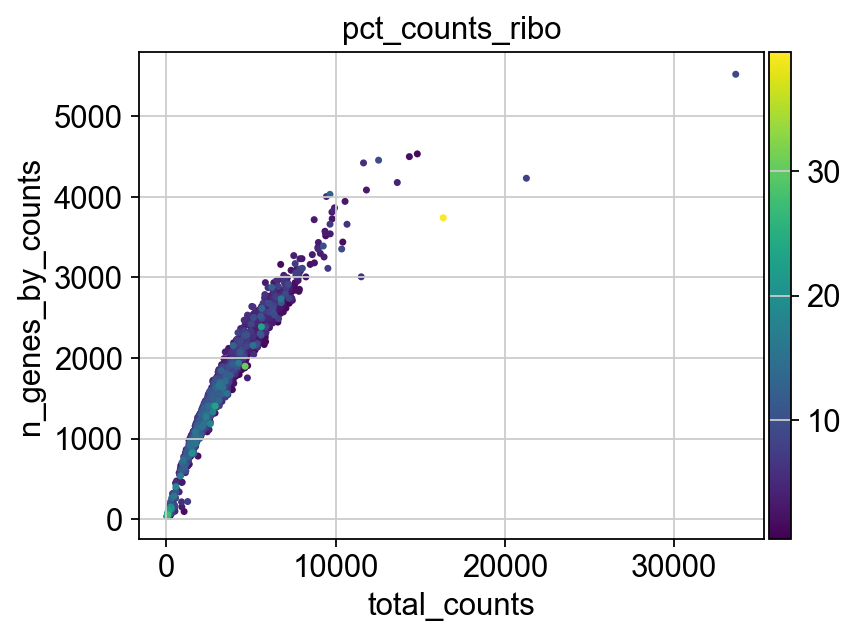

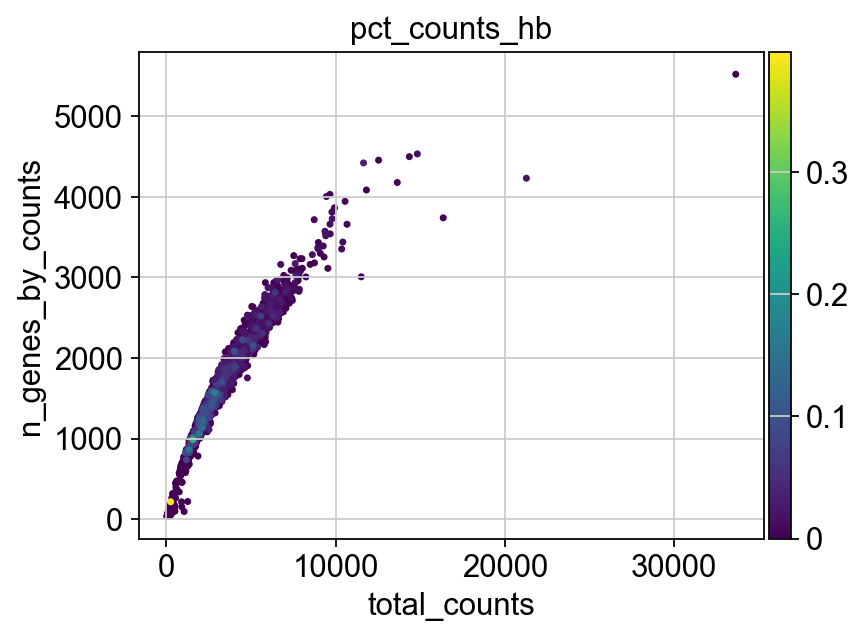

In [7]:
# ============================================
# QC scatter plots: total counts vs genes before filtering
# colored by mitochondrial / ribosomal / HB %
# ============================================

qc_metrics = [
    "pct_counts_mt",
    "pct_counts_ribo",
    "pct_counts_hb",
]

for qc in qc_metrics:
    sc.pl.scatter(
        adata_rna,
        x="total_counts",
        y="n_genes_by_counts",
        color=qc,
        title=qc,
        show=True
    )

In [8]:
# ===============================
# QC-based cell filtering
# ===============================

from multiomic_vae.data.preprocess_rna import filter_cells_by_qc

adata_rna = filter_cells_by_qc(
    adata_rna,
    max_mt_pct=25,
    max_ribo_pct=15,
    max_hb_pct=None
)

adata_rna

AnnData object with n_obs × n_vars = 2887 × 36601
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

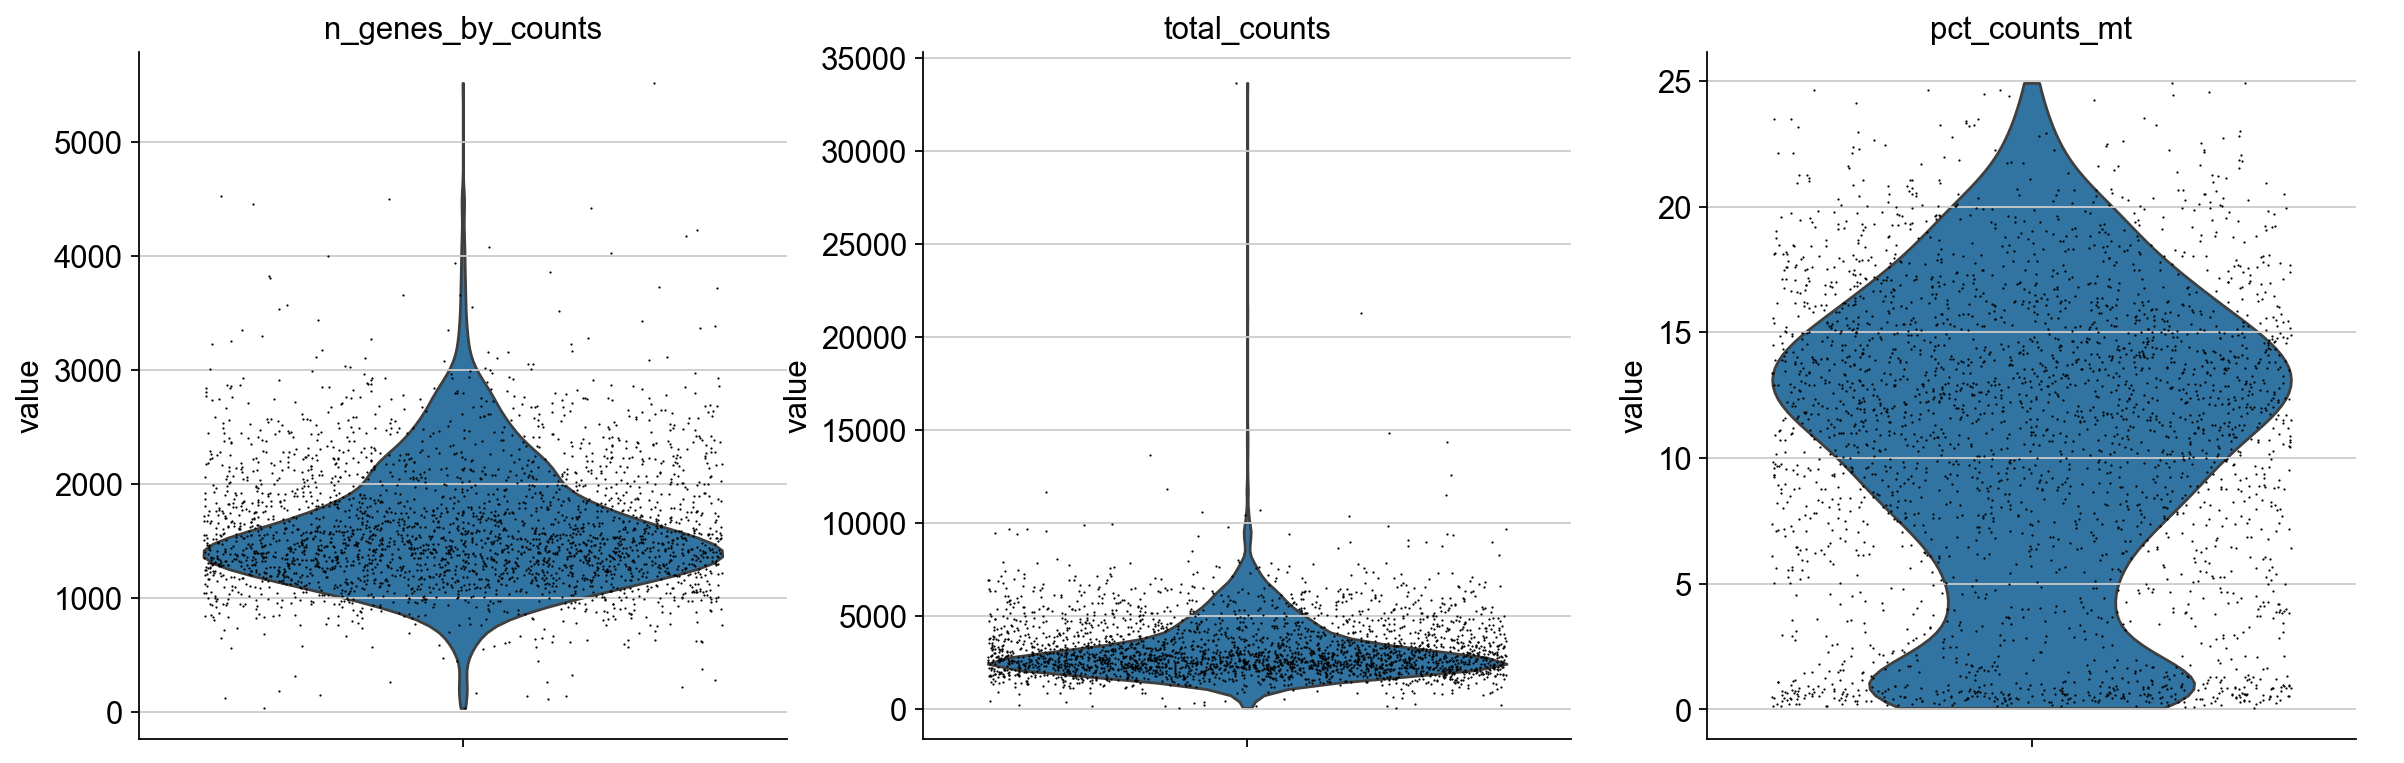

In [9]:
# ===============================
# QC visualization: mitochondrial genes after filtering
# ===============================

sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

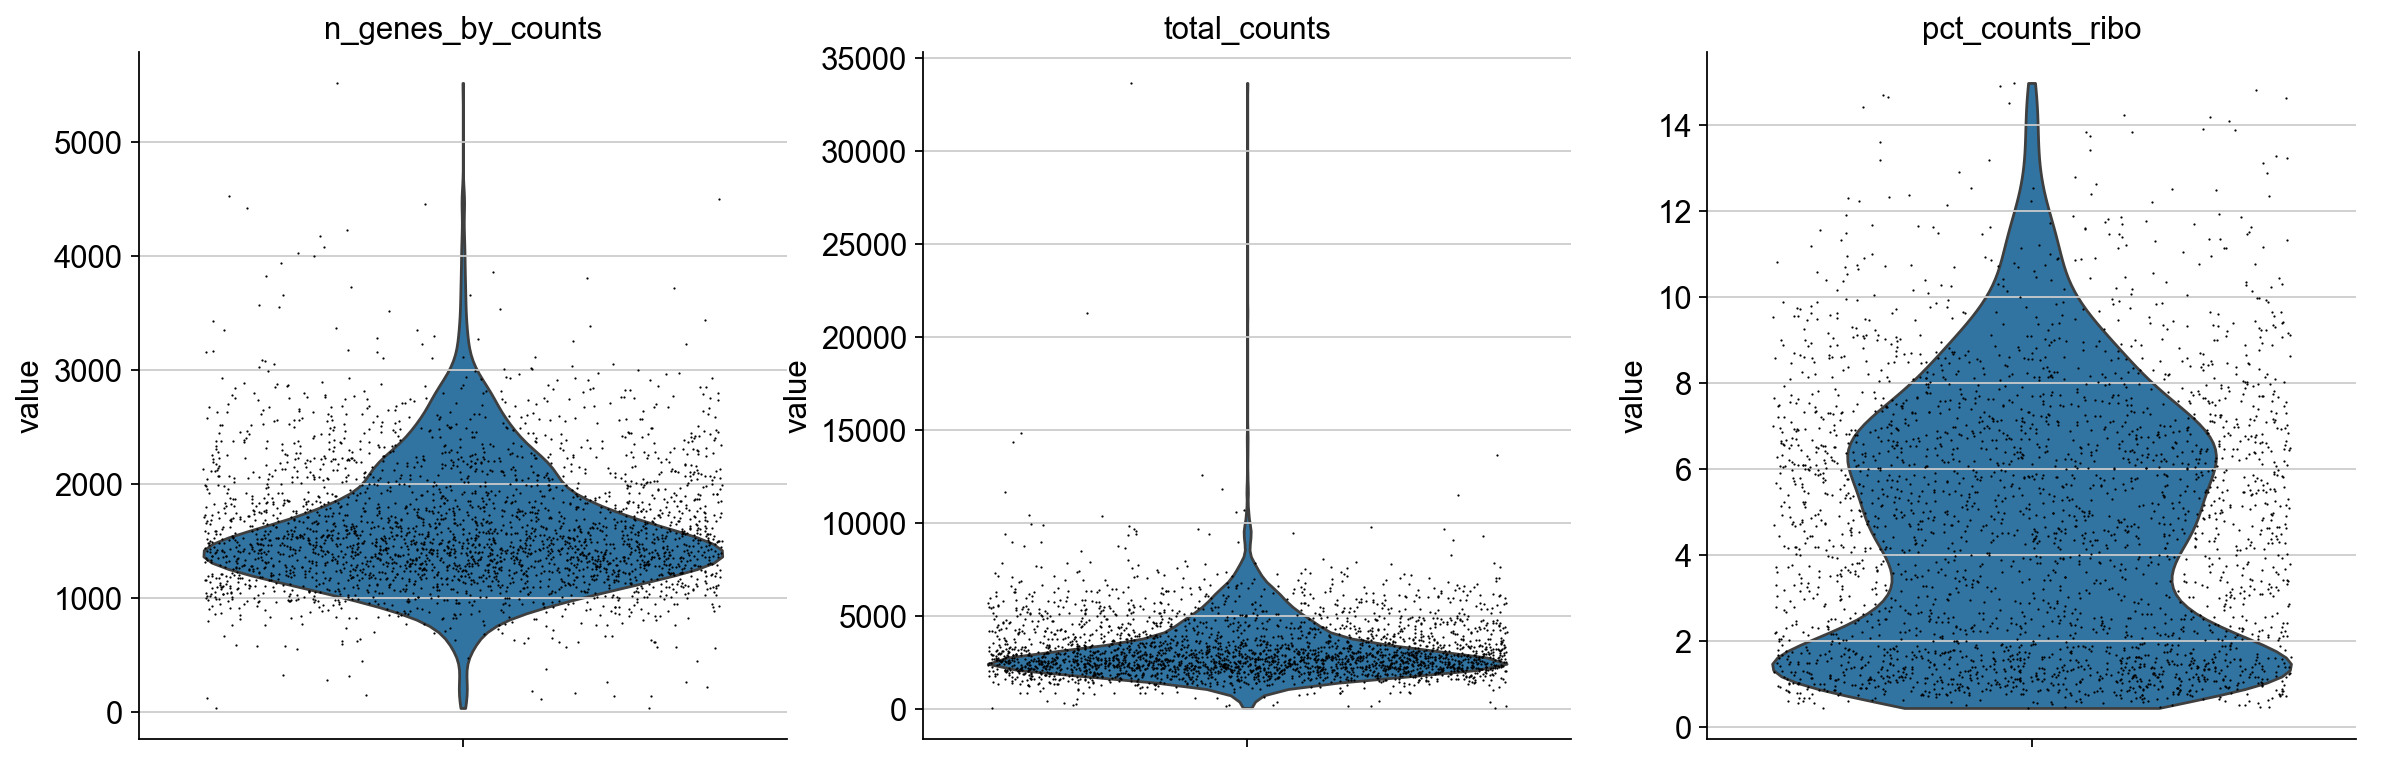

In [10]:
# ===============================
# QC visualization: ribosomal genes after filtering
# ===============================

sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True
)

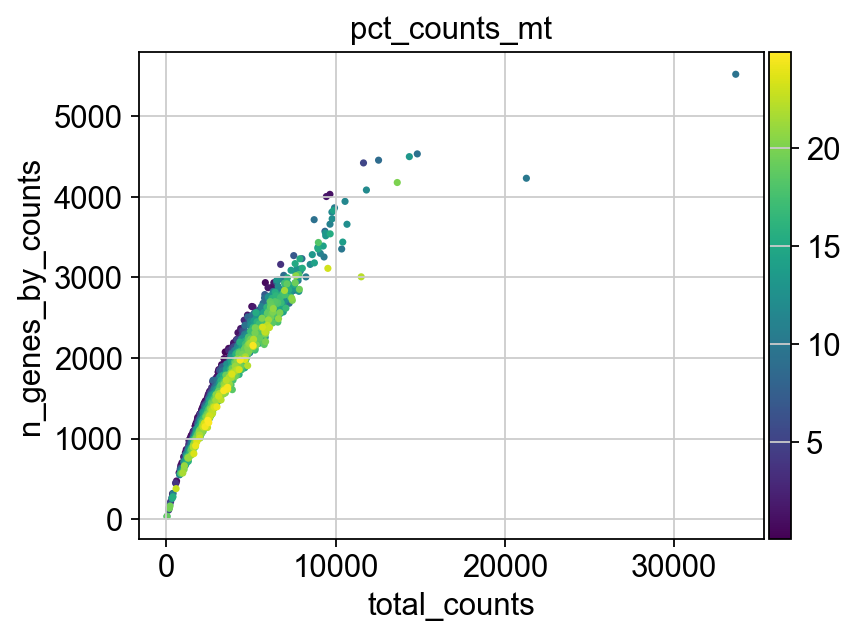

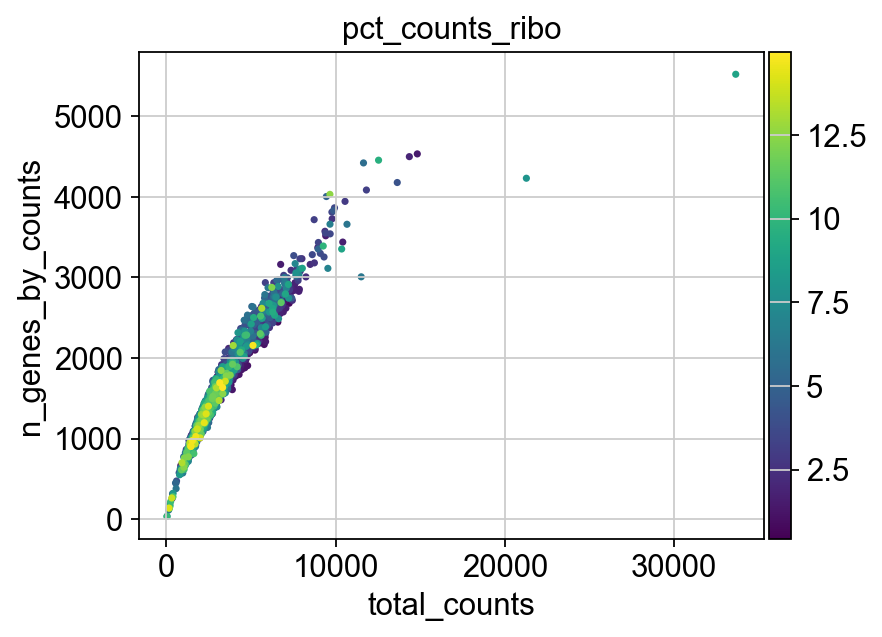

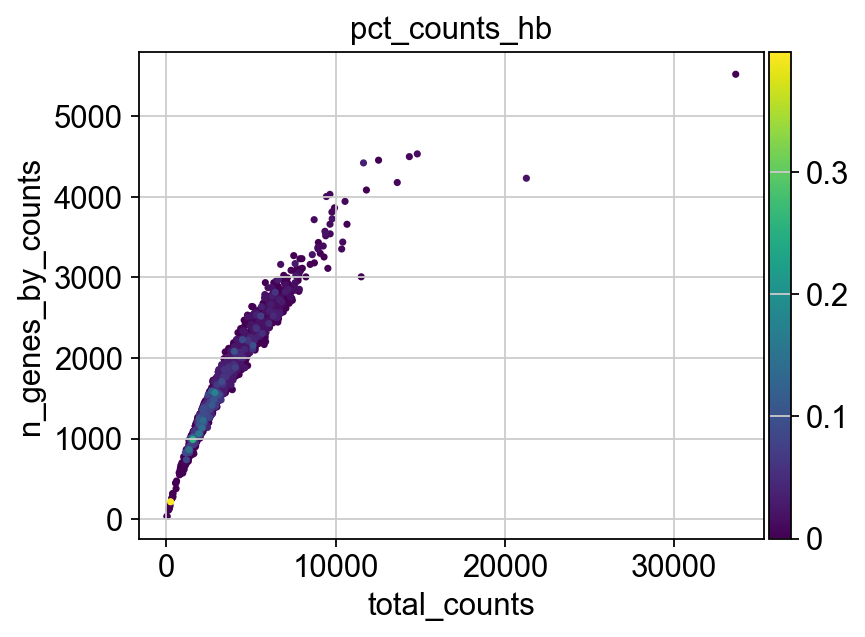

In [11]:
# ============================================
# QC scatter plots: total counts vs genes after filtering
# colored by mitochondrial / ribosomal / HB %
# ============================================

qc_metrics = [
    "pct_counts_mt",
    "pct_counts_ribo",
    "pct_counts_hb",
]

for qc in qc_metrics:
    sc.pl.scatter(
        adata_rna,
        x="total_counts",
        y="n_genes_by_counts",
        color=qc,
        title=qc,
        show=True
    )

### 1.2) Cell- and gene-level filtering

In [12]:
# ===============================
# Filter low-quality cells and genes
# ===============================

from multiomic_vae.data.preprocess_rna import filter_cells_genes

adata_rna = filter_cells_genes(
    adata_rna,
    min_genes=100,
    min_cells=3
)

adata_rna

AnnData object with n_obs × n_vars = 2885 × 21271
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

### 1.3) Doublet Detection

In [13]:
# ===============================
# Doublet detection
# ===============================

from multiomic_vae.data.preprocess_rna import detect_doublets

adata_rna = detect_doublets(adata_rna)

adata_rna.obs[["predicted_doublet", "doublet_score"]].head()


,predicted_doublet,doublet_score
AAACAGCCAACAGGTG-1,False,0.033216
AAACATGCAACAACAA-1,False,0.049151
AAACCAACACAGCCTG-1,False,0.020728
AAACCAACAGCAAGAT-1,False,0.106583
AAACCAACATTGCGAC-1,False,0.026250


### 1.4) Log1p noramlization of counts

In [14]:
# ============================================
# Normalize RNA data (counts → log1p)
# ============================================

from multiomic_vae.data.preprocess_rna import normalize_log1p

adata_rna = normalize_log1p(adata_rna)


### 1.5) HVGs selection

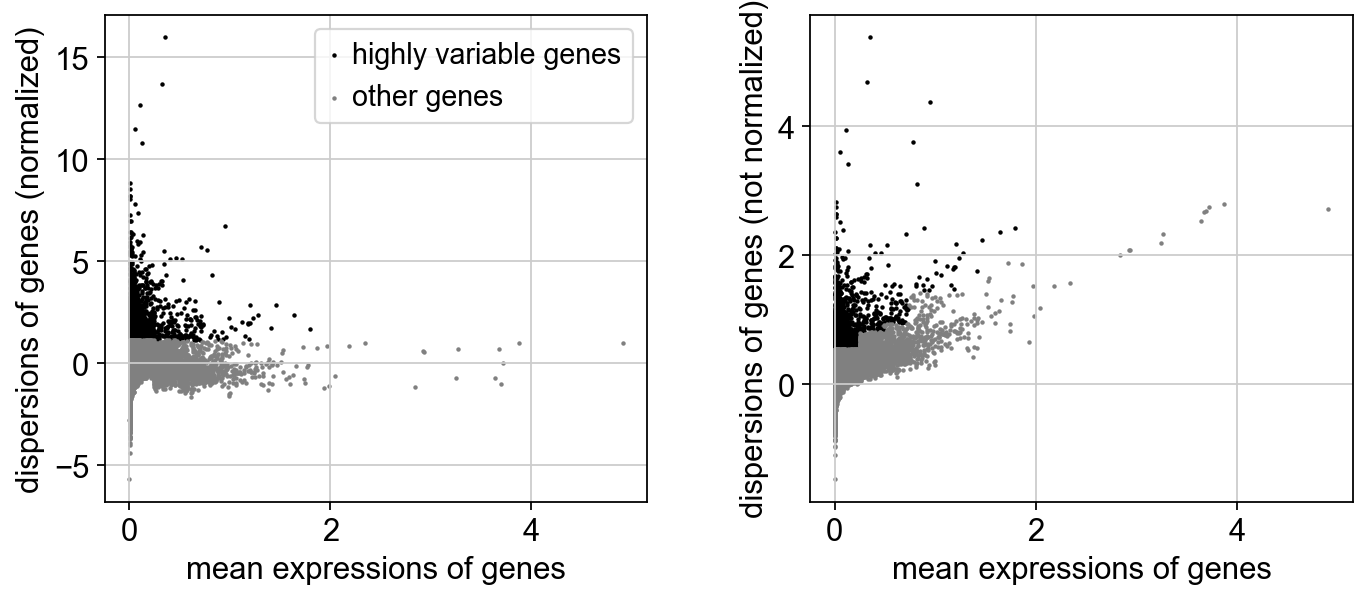

In [15]:
# ============================================
# Select highly variable genes (HVGs)
# - tag top variable genes per sample
# - no filtering applied yet
# ============================================

from multiomic_vae.data.preprocess_rna import select_hvgs

adata_rna = select_hvgs(adata_rna, n_top_genes=2000)
sc.pl.highly_variable_genes(adata_rna)

### 1.6) PCA

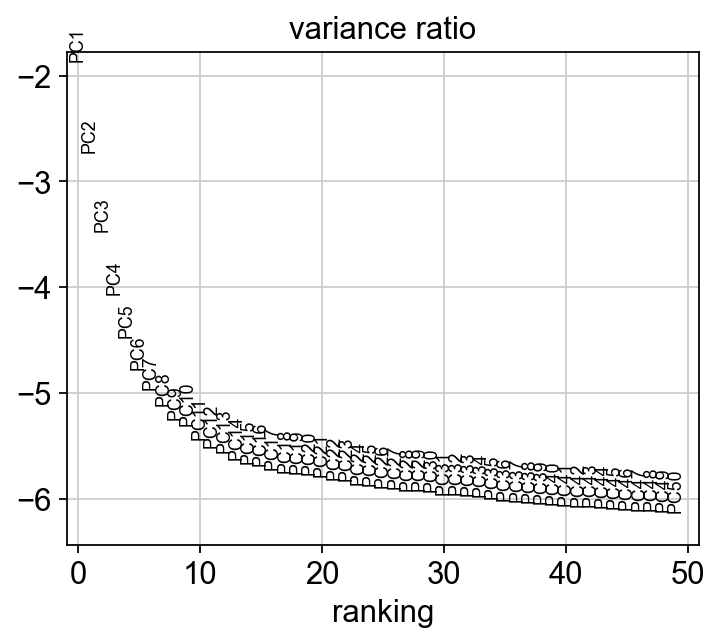

In [16]:
# ============================================
# PCA on RNA data
# - run PCA on selected genes (HVGs)
# - prepare for neighbors / UMAP
# ============================================

from multiomic_vae.data.preprocess_rna import run_pca

adata_rna = run_pca(adata_rna, n_comps=50)
sc.pl.pca_variance_ratio(adata_rna, n_pcs=50, log=True)

### 1.7) UMAP and Leidens
NOTE: Clustering results shown at this stage are for exploratory purposes only and are not used for model training or final evaluation.

C:\Users\user\anaconda3\envs\peakvi\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


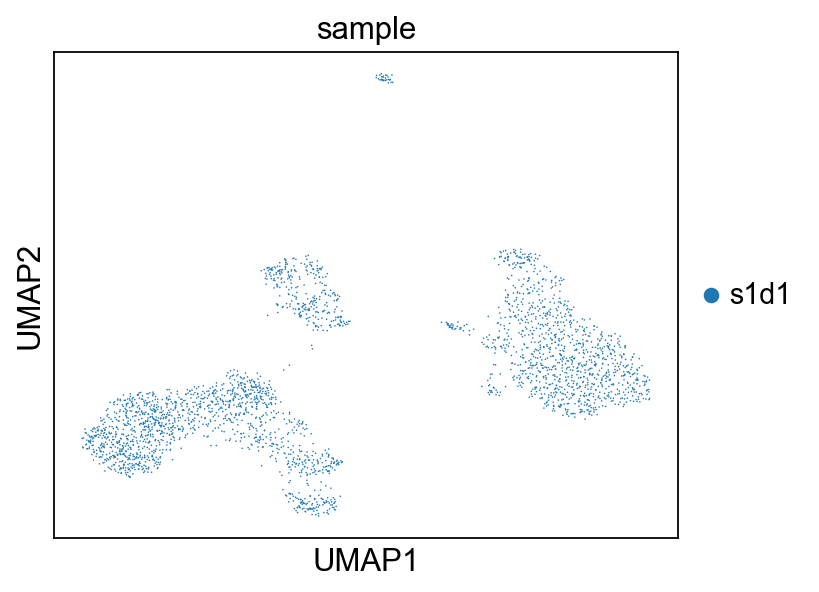

In [17]:
# ============================================
# Neighbors graph + UMAP
# ============================================

from multiomic_vae.data.preprocess_rna import run_neighbors_umap

adata_rna = run_neighbors_umap(
    adata_rna,
    n_neighbors=15,
    n_pcs=50
)

sc.pl.umap(adata_rna, color="sample", size=2)

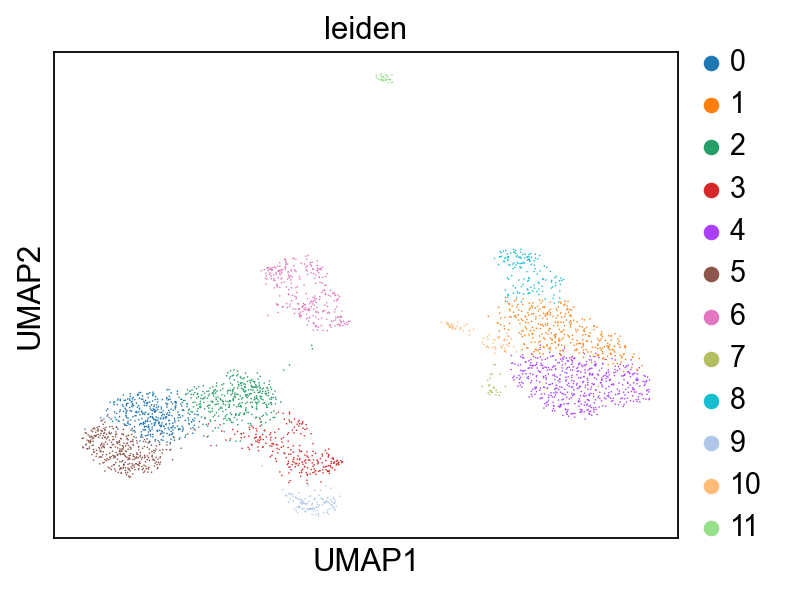

In [18]:
# ============================================
# Leiden clustering
# ============================================

from multiomic_vae.data.preprocess_rna import run_leiden

adata_rna = run_leiden(adata_rna)
sc.pl.umap(adata_rna, color="leiden", size=2)

### 1.8) Convert to Cell*Gene preprocessed to Dataframe

In [19]:
# ===============================
# Convert AnnData to cell × gene DataFrame
# ===============================

df_rna = pd.DataFrame(
    adata_rna.X.toarray(),
    index=adata_rna.obs_names,   # cell identifiers
    columns=adata_rna.var_names  # gene identifiers
)

print(df_rna.shape)
df_rna.head()

(2885, 21271)


,AL627309.1,AL627309.5,AL627309.4,AL669831.2,LINC01409,LINC01128,LINC00115,FAM41C,AL645608.6,SAMD11,...,MT-ND5,MT-ND6,MT-CYB,BX004987.1,MAFIP,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC007325.4
AAACAGCCAACAGGTG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.174549,0.000000,3.763763,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AAACATGCAACAACAA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.312793,0.530746,2.557491,0.0,0.0,0.0,0.530746,0.0,0.0,0.0
AAACCAACACAGCCTG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.839741,0.000000,3.823272,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AAACCAACAGCAAGAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.022007,0.000000,3.646862,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AAACCAACATTGCGAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.033162,1.788194,3.624610,0.0,0.0,0.0,0.978157,0.0,0.0,0.0


# 2) Building Cell * Peak
Single-cell ATAC-seq data consists of **fragment files** (mapping each read to a genomic interval per cell) and a **peaks file** (defining the genomic regions to aggregate fragments into a cell × peak matrix).


In [20]:
# ============================================
# Load and inspect ATAC fragments and peaks
# ============================================

from multiomic_vae.utils.cell_peak_utils import load_fragments, load_peaks

atac_fragments_path = DATA_DIR / "pbmc_3k" / "pbmc_unsorted_3k_atac_fragments.tsv.gz"
atac_peaks_path = DATA_DIR / "pbmc_3k" / "pbmc_unsorted_3k_atac_peaks.bed"

fragments_df = load_fragments(atac_fragments_path)
peaks_df = load_peaks(atac_peaks_path)

peaks_df.head()

,Chromosome,Start,End
0,chr1,9782,10672
1,chr1,180547,181446
2,chr1,191121,191998
3,chr1,267553,268447
4,chr1,270906,271782


In [21]:
fragments_df.head()

,Chromosome,Start,End,Barcode,Count
0,chr1,10073,10431,CAAGGGAGTAAGCTCA-1,1
1,chr1,10085,10279,ACAGGTAAGCTTTGGG-1,1
2,chr1,10085,10335,GGTTAATGTACTTCAC-1,1
3,chr1,10091,10339,TGTTGGCCAAGGAATC-1,1
4,chr1,10150,10192,CCCTTAATCATCCTCA-1,2


In [22]:
# ============================================
# Filter ATAC fragments
# - keep standard chromosomes
# - remove extreme fragment lengths
# - drop low-quality cells (low fragment counts)
# ============================================

from multiomic_vae.utils.cell_peak_utils import filter_fragments

fragments_df = filter_fragments(fragments_df)

After removing unwanted chromosomes: 52,996,516
After fragment length filtering: 44,356,982
After removing low-quality cells: 40,839,377


In [23]:
# ============================================
# Filter ATAC peaks
# - keep standard chromosomes
# - no peak IDs assigned at this stage
# ============================================

from multiomic_vae.utils.cell_peak_utils import filter_peaks

peaks_df = filter_peaks(peaks_df)

Peaks kept after filtering: 81,111


In [24]:
# ============================================
# Assign peak IDs (chr_start_end)
# ============================================

from multiomic_vae.utils.cell_peak_utils import assign_peak_ids

peaks_df = assign_peak_ids(peaks_df)

In [25]:
peaks_df.head()

,Chromosome,Start,End,PeakID
0,chr1,9782,10672,chr1_9782_10672
1,chr1,180547,181446,chr1_180547_181446
2,chr1,191121,191998,chr1_191121_191998
3,chr1,267553,268447,chr1_267553_268447
4,chr1,270906,271782,chr1_270906_271782


In [26]:
# ============================================
# Map ATAC fragments to peaks
# - assign each fragment to overlapping peaks
# - output (Barcode, PeakID) pairs
# ============================================

from multiomic_vae.utils.cell_peak_utils import map_fragments_to_peaks

mapped_fragments = map_fragments_to_peaks(fragments_df, peaks_df)

Processing 24 chromosomes...
chr1: 8,019 chunks appended
chr10: 11,783 chunks appended
chr11: 15,816 chunks appended
chr12: 20,012 chunks appended
chr13: 21,822 chunks appended
chr14: 24,589 chunks appended
chr15: 27,292 chunks appended
chr16: 30,182 chunks appended
chr17: 34,615 chunks appended
chr18: 36,111 chunks appended
chr19: 40,043 chunks appended
chr2: 46,330 chunks appended
chr20: 48,681 chunks appended
chr21: 49,705 chunks appended
chr22: 51,588 chunks appended
chr3: 56,436 chunks appended
chr4: 59,577 chunks appended
chr5: 63,495 chunks appended
chr6: 68,470 chunks appended
chr7: 72,341 chunks appended
chr8: 75,576 chunks appended
chr9: 78,851 chunks appended
chrX: 81,096 chunks appended
chrY: 81,110 chunks appended
Final mapped rows: 15,495,783


In [27]:
# ============================================
# Build cell × peak count matrix
# ============================================

from multiomic_vae.utils.cell_peak_utils import build_peak_matrix

cell_peak_df = build_peak_matrix(mapped_fragments)
cell_peak_df.head()

DataFrame built: (2887, 81110)


PeakID,chr10_100006146_100007016,chr10_100009472_100010363,chr10_100014089_100014984,chr10_100020111_100021021,chr10_100045764_100046668,chr10_100167389_100168314,chr10_100182021_100182688,chr10_100183185_100184091,chr10_100185613_100186527,chr10_100229097_100229937,...,chrY_11295148_11295881,chrY_11304911_11305591,chrY_11312090_11312962,chrY_11314447_11315142,chrY_11320525_11321371,chrY_11322280_11322995,chrY_11323118_11323755,chrY_11332864_11333512,chrY_11333632_11334281,chrY_56846844_56847757
Barcode,,,,,,,,,,,,,,,,,,,,,
AAACAGCCAACAGGTG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACATGCAACAACAA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACATGCACCTGGTG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCAACACAGCCTG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCAACAGCAAGAT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 3) Preprocessing Cell * Peak

In [28]:
# ===============================
# Compute peak activity across cells
# peak_counts: number of cells where each peak is active
# peak_frac: fraction of cells in which each peak is accessible
# ===============================

from multiomic_vae.data.preprocessing_peak import compute_peak_activity

peak_counts, peak_frac = compute_peak_activity(cell_peak_df)

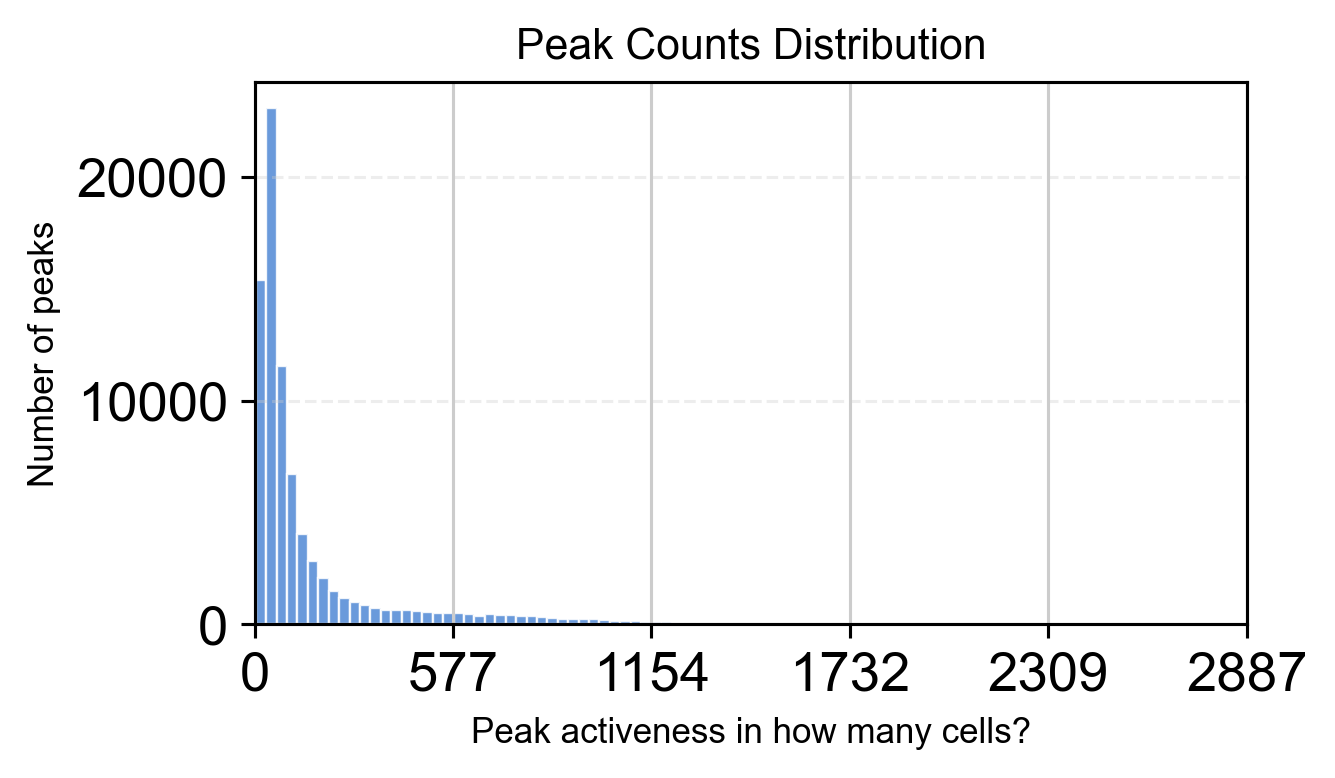

In [29]:
# ===============================
# Visualize peak activity distribution
# Shows how many cells each peak is active in
# ===============================

from multiomic_vae.data.preprocessing_peak import plot_peak_activity

n_cells = cell_peak_df.shape[0]
plot_peak_activity(peak_counts, n_cells)


In [30]:
# ===============================
# Peak retention under different activity thresholds
# Shows how many peaks remain if we require minimum activity across cells
# ===============================

from multiomic_vae.data.preprocessing_peak import print_peak_threshold_summary

print_peak_threshold_summary(peak_frac)

Peaks active in ≥1% of cells: 69750
Peaks active in ≥2% of cells: 45434
Peaks active in ≥3% of cells: 32858
Peaks active in ≥4% of cells: 25784
Peaks active in ≥5% of cells: 21374


In [31]:
# ===============================
# Filter peaks based on activity fraction
# Retain peaks active in at least 3% of cells
# ===============================

from multiomic_vae.data.preprocessing_peak import filter_peaks_by_fraction

cell_peak_df_filtered, peak_mask = filter_peaks_by_fraction(
    cell_peak_df,
    peak_frac,
    min_frac=0.03
)

cell_peak_df_filtered.shape

(2887, 32858)

In [32]:
# ===============================
# Compute sparsity of cell × peak matrix
# Measures fraction of zero entries in the matrix
# ===============================

from multiomic_vae.data.preprocessing_peak import compute_sparsity

sparsity_before = compute_sparsity(cell_peak_df)
sparsity_after = compute_sparsity(cell_peak_df_filtered)

sparsity_before, sparsity_after

(np.float64(0.9441613220992399), np.float64(0.8847919513769645))

In [33]:
# ===============================
# Apply log(1 + x) transformation to peak matrix
# Stabilizes variance before model training
# ===============================

from multiomic_vae.data.preprocessing_peak import log1p_peak_matrix

cell_peak_df_log = log1p_peak_matrix(cell_peak_df_filtered)

# 4) Harmonization of Cell * Gene - Cell * Peak matrices

In [34]:
# ===============================
# Align cells between RNA and peak modalities
# Retain only cells present in both matrices
# ===============================


from multiomic_vae.data.harmonization import align_cells_between_modalities

cell_peak_df_aligned, df_rna_aligned = align_cells_between_modalities(
    cell_peak_df_log,
    df_rna
)

cell_peak_df_aligned.shape, df_rna_aligned.shape

((2710, 32858), (2710, 21271))

# 5) Saving Preprocessed data

In [109]:
# ===============================
# Save preprocessed cell × peak matrix
# ===============================

from multiomic_vae.utils.io_utils import save_sparse_matrix

save_sparse_matrix(
    cell_peak_df_aligned,
    PROCESSED_DATA_DIR / "pbmc_3k" / "cell_peak_preprocessed.npz"
)

In [110]:
# ===============================
# Save preprocessed cell × peak matrix
# ===============================

from multiomic_vae.utils.io_utils import save_sparse_matrix

save_sparse_matrix(
    df_rna_aligned,
    PROCESSED_DATA_DIR / "pbmc_3k" / "cell_gene_preprocessed.npz"
)

In [114]:
# ===============================
# Create and save aligned RNA Leiden cluster labels
# Subset original clustering to shared cells and store for evaluation
# ===============================

import os

leiden_aligned = pd.DataFrame({
    "cell_id": df_rna_aligned.index,
    "leiden": adata_rna.obs.loc[df_rna_aligned.index, "leiden"].astype(str)
})

output_dir = PROCESSED_DATA_DIR / "pbmc_3k"
os.makedirs(output_dir, exist_ok=True)

leiden_aligned.to_csv(
    output_dir / "rna_leiden_labels.csv",
    index=False
)

leiden_aligned.head()

,cell_id,leiden
AAACAGCCAACAGGTG-1,AAACAGCCAACAGGTG-1,0
AAACATGCAACAACAA-1,AAACATGCAACAACAA-1,1
AAACCAACACAGCCTG-1,AAACCAACACAGCCTG-1,0
AAACCAACAGCAAGAT-1,AAACCAACAGCAAGAT-1,2
AAACCAACATTGCGAC-1,AAACCAACATTGCGAC-1,0
